In [1]:
import numpy as np
import pylab as plt

In [2]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x141c89a5250>)

In [3]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


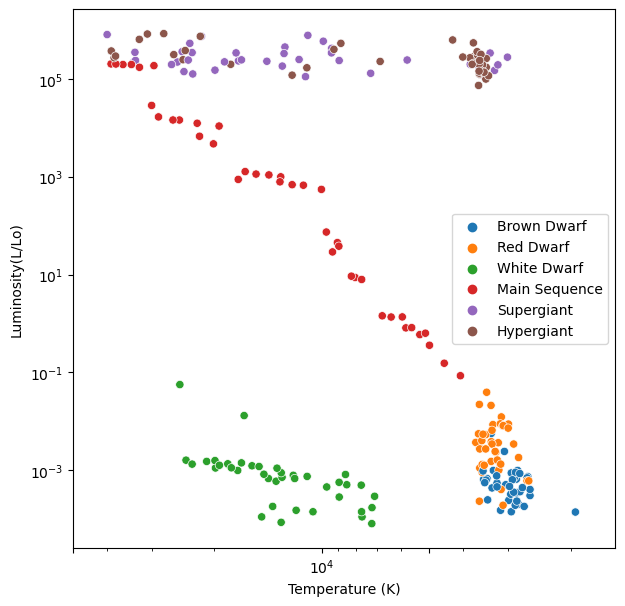

In [5]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()


In [6]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,1,Blue,O
236,30839,834042.000000,1194.0000,-10.63,1,Blue,O
237,8829,537493.000000,1423.0000,-10.73,1,White,A
238,9235,404940.000000,1112.0000,-11.23,1,White,A


In [7]:
#taking just the float part of dataset

data = df_stars.to_numpy()
cleaned_data = np.column_stack((data[:,0],data[:,1],data[:,2],data[:,3]))
float_data = np.asfarray(cleaned_data, dtype = float)

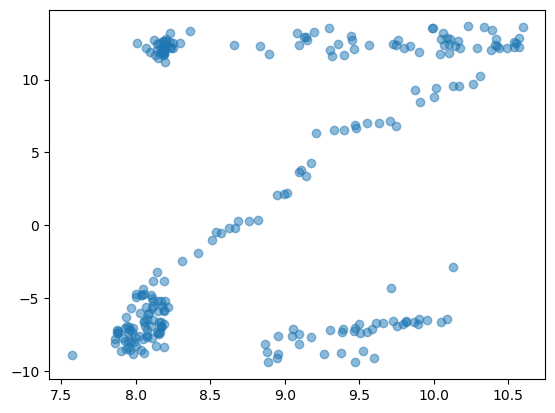

In [8]:
plt.scatter(np.log(float_data[:,0]) , np.log((float_data[: , 1])), alpha = 0.5)

In [9]:
log_data = np.column_stack((np.log(float_data[:,0]),np.log(float_data[:,1]),np.log(float_data[:,2]),float_data[:,3]))


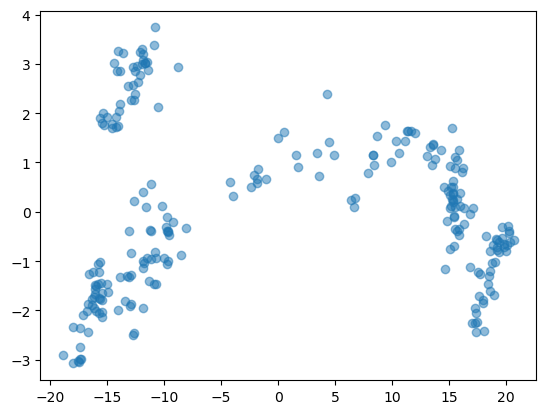

In [10]:
#doing PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca.fit(log_data)

X = pca.transform(log_data)

plt.scatter (X[: , 0] , X[: , 1], alpha = 0.5)
plt.show()

In [11]:
#rescaling dataset

#Rescaling parameters
R_temp = np.exp(1/max(float_data[:,0]))
R_mag = 0.0001
R_lum  = np.exp(100)
R_rad = np.exp(1/max(float_data[:,2]))

#rescaled data
R_data = np.column_stack((np.log(float_data[:,0] *R_temp), np.log(R_lum * float_data[:,1]),np.log( R_rad * float_data[:,2]),R_mag * float_data[:,3]))

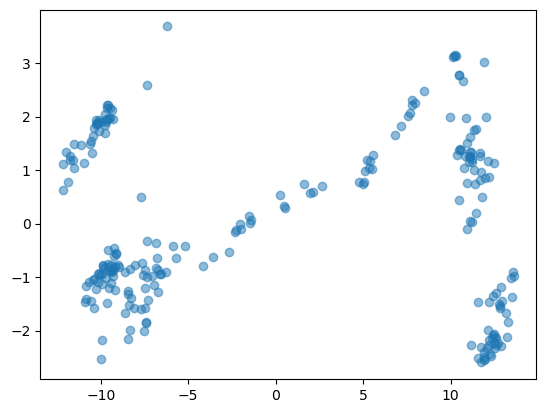

In [12]:
#PCA-ing the reduced dataset and plotting the result
pca.fit(R_data)

R_X = pca.transform(R_data)
plt.scatter (R_X[: , 0] , R_X[: , 1], alpha = 0.5)
plt.show()

In [13]:
np.max(abs(log_data) , axis = 0)

array([10.59663473, 13.65230904,  7.57481512, 20.06      ])

 ## Massaging the data in order to make it more PCA-friendly

In [14]:
mean = np.mean(log_data , axis = 0)
var = np.var(log_data , axis = 0)
d = (log_data - mean) / (np.sqrt(var))
dataset = np.column_stack((d[:,0], d[:,1],d[:,2],d[:,3]))


PCA-ing the new dataset: 

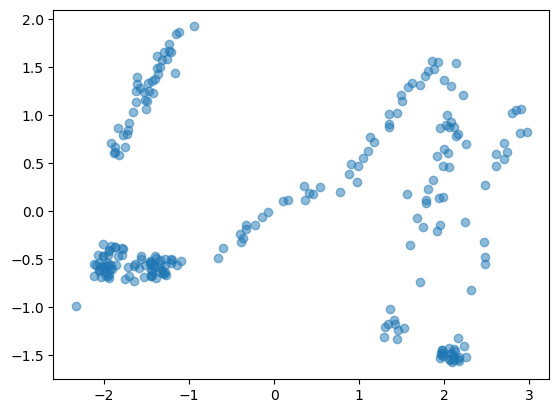

In [15]:
pca.fit(dataset)

X_pca = pca.transform(dataset)

plt.scatter (X_pca[:,0],X_pca[:,1], alpha = 0.5)

variance explained by this PCA:

In [16]:
var_got = pca.explained_variance_ratio_ 
var_got[0] * 100

76.16293437299461

does it change if i change pca components?

In [17]:
pca3 = PCA(n_components = 3) 
pca3.fit(dataset)
var3_got = pca3.explained_variance_ratio_
print(var3_got , var_got)

[0.76162934 0.22012559 0.01245219] [0.76162934 0.22012559]


no

## Clustering just for fun

In [18]:
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()

bandwidth =   0.6
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform(X_pca))

labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])

In [19]:
n_clusters

6

In [20]:
# Set a n_clusters KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=0)

# Compute cluster centers and predict cluster indices
X_clustered = kmeans.fit_predict(X_pca)

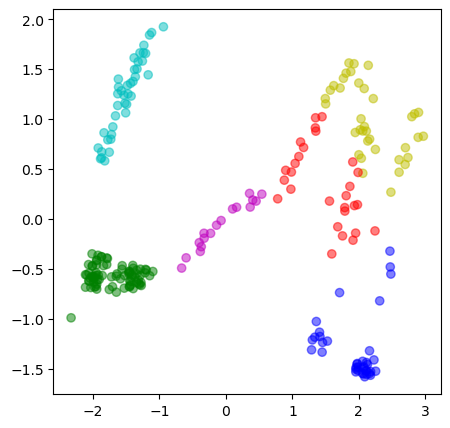

In [21]:
#plotting the result
LABEL_COLOR_MAP = {0 : 'r',
                   1 : 'g',
                   2 : 'b',
                   3 : 'c',
                   4 : 'm',
                   5 : 'y',
                   6 : 'k',
                   7 : '0',
                   8 : '1',
                   9 : '0.8',
                   10 : 'w'}

label_color = [LABEL_COLOR_MAP[l] for l in X_clustered]
plt.figure(figsize = (5,5))
plt.scatter(X_pca[:,0],X_pca[:,1], c= label_color, alpha=0.5)
plt.show()

(check it with another method)